# Reproduce the `squidpy.datasets.cells` dataset

In this notebook, we will reproduce the creation of the `squidpy.datasets.cells` dataset from raw data. It's a real but minimal dataset used for testing and demonstration purposes in the Squidpy library.

First, we download the raw data of the [Xenium Prime Cervical Cancer FFPE dataset from 10x Genomics](https://www.10xgenomics.com/datasets/xenium-prime-ffpe-human-cervical-cancer):

```
# download raw data
curl -O https://s3-us-west-2.amazonaws.com/10x.files/samples/xenium/3.0.0/Xenium_Prime_Cervical_Cancer_FFPE/Xenium_Prime_Cervical_Cancer_FFPE_outs.zip
curl -O https://cf.10xgenomics.com/samples/xenium/3.0.0/Xenium_Prime_Cervical_Cancer_FFPE/Xenium_Prime_Cervical_Cancer_FFPE_he_image.ome.tif
curl -O https://cf.10xgenomics.com/samples/xenium/3.0.0/Xenium_Prime_Cervical_Cancer_FFPE/Xenium_Prime_Cervical_Cancer_FFPE_he_imagealignment.csv
curl -O https://cf.10xgenomics.com/samples/xenium/3.0.0/Xenium_Prime_Cervical_Cancer_FFPE/Xenium_Prime_Cervical_Cancer_FFPE_gene_panel.json

# prepare files for spatialdata-io ingestion
unzip Xenium_Prime_Cervical_Cancer_FFPE_outs.zip -d Xenium_Prime_Cervical_Cancer_FFPE_outs
mv Xenium_Prime_Cervical_Cancer_FFPE_he_image.ome.tif Xenium_Prime_Cervical_Cancer_FFPE_outs/
mv Xenium_Prime_Cervical_Cancer_FFPE_he_imagealignment.csv Xenium_Prime_Cervical_Cancer_FFPE_outs/
mv Xenium_Prime_Cervical_Cancer_FFPE_gene_panel.json Xenium_Prime_Cervical_Cancer_FFPE_outs/
```

In [1]:
import spatialdata as sd
from spatialdata import rasterize, get_extent

import spatialdata_io as sdio 
import spatialdata_plot as sdp 
import squidpy as sq
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import numpy as np

from spatialdata.transformations import get_transformation
from spatialdata.models import Image2DModel

/ictstr01/groups/ml01/workspace/ttreis/projects/spatialdata-notebooks/notebooks/examples/.pixi/envs/default/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1) Create `SpatialData` object from raw data

We first ingest the entire data and will then gradually process it.

In [2]:
sdata = sdio.xenium(
    "Xenium_Prime_Cervical_Cancer_FFPE_outs",
    image_models_kwargs={"scale_factors": [2]},
    labels_models_kwargs={"scale_factors": [2]},
)
sdata

SpatialData object
├── Images
│     ├── 'he_image': DataTree[cyx] (3, 46545, 38219), (3, 23272, 19109)
│     └── 'morphology_focus': DataTree[cyx] (4, 51205, 54125), (4, 25602, 27062)
├── Labels
│     ├── 'cell_labels': DataTree[yx] (51205, 54125), (25602, 27062)
│     └── 'nucleus_labels': DataTree[yx] (51205, 54125), (25602, 27062)
├── Points
│     └── 'transcripts': DataFrame with shape: (<Delayed>, 13) (3D points)
├── Shapes
│     ├── 'cell_boundaries': GeoDataFrame shape: (840387, 1) (2D shapes)
│     └── 'nucleus_boundaries': GeoDataFrame shape: (839632, 2) (2D shapes)
└── Tables
      └── 'table': AnnData (840387, 5101)
with coordinate systems:
    ▸ 'global', with elements:
        he_image (Images), morphology_focus (Images), cell_labels (Labels), nucleus_labels (Labels), transcripts (Points), cell_boundaries (Shapes), nucleus_boundaries (Shapes)

Let's first visualise the H&E image. If we zoom in, we can spot a tiny piece of tissue
that detached from the rest but is still within the main capture area. That probably
means it was still processed exactly the same as the rest of the tissue. The code below
draws a red box around the detached piece of tissue.

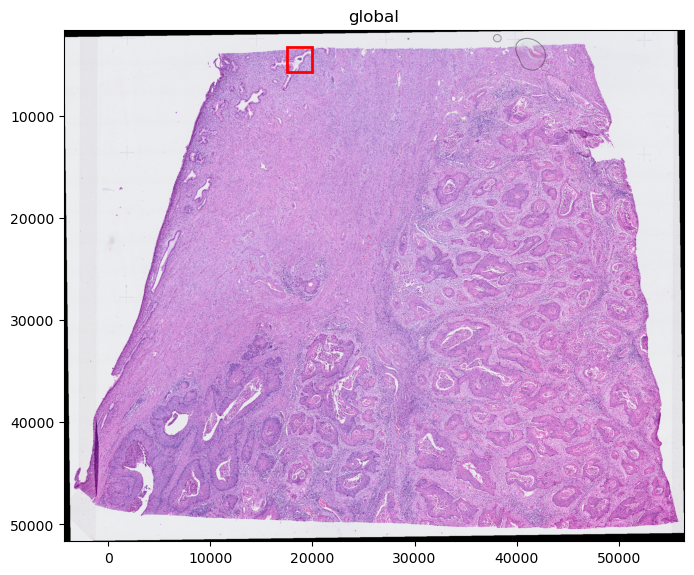

In [3]:
fig, ax = plt.subplots(ncols=1, nrows=1, figsize=(8,8))

(
    sdata
    .pl.render_images("he_image")
    .pl.show(ax=ax)
)

ax.add_patch(
    Rectangle(
        (17_500, 3_250),
        2_500,
        2_500,
        edgecolor="red",
        facecolor="none",
        linewidth=2)
)



Now let's subset the `SpatialData` object to only that tiny piece of tissue.

In [4]:
cropped = sdata.query.bounding_box(
    axes=("x", "y"),
    min_coordinate=[18_480, 4_330],
    max_coordinate=[19_020, 4_760],
    target_coordinate_system="global",
    filter_table=True,
)

/ictstr01/groups/ml01/workspace/ttreis/projects/spatialdata-notebooks/notebooks/examples/.pixi/envs/default/lib/python3.14/functools.py:982: UserWarning: The object has `points` element. Depending on the number of points, querying MAY suffer from performance issues. Please consider filtering the object before calling this function by calling the `subset()` method of `SpatialData`.
  return dispatch(args[0].__class__)(*args, **kw)


In [5]:
cropped

SpatialData object
├── Images
│     ├── 'he_image': DataTree[cyx] (3, 423, 339), (3, 211, 169)
│     └── 'morphology_focus': DataTree[cyx] (4, 430, 540), (4, 215, 270)
├── Labels
│     ├── 'cell_labels': DataTree[yx] (430, 540), (215, 270)
│     └── 'nucleus_labels': DataTree[yx] (430, 540), (215, 270)
├── Points
│     └── 'transcripts': DataFrame with shape: (<Delayed>, 13) (3D points)
├── Shapes
│     ├── 'cell_boundaries': GeoDataFrame shape: (94, 1) (2D shapes)
│     └── 'nucleus_boundaries': GeoDataFrame shape: (94, 2) (2D shapes)
└── Tables
      └── 'table': AnnData (94, 5101)
with coordinate systems:
    ▸ 'global', with elements:
        he_image (Images), morphology_focus (Images), cell_labels (Labels), nucleus_labels (Labels), transcripts (Points), cell_boundaries (Shapes), nucleus_boundaries (Shapes)

In [6]:
# 1st write for performance in downstream operations
cropped.write("cells_dataset.zarr", overwrite=True)
cropped = sd.read_zarr("cells_dataset.zarr")

/ictstr01/groups/ml01/workspace/ttreis/projects/spatialdata-notebooks/notebooks/examples/.pixi/envs/default/lib/python3.14/site-packages/pims/tiff_stack.py:131: UserWarning: <tifffile.TiffPage 0 @16> reading array from closed file
  data = t.asarray()
/ictstr01/groups/ml01/workspace/ttreis/projects/spatialdata-notebooks/notebooks/examples/.pixi/envs/default/lib/python3.14/site-packages/dask/utils.py:782: UserWarning: Could not serialize pd.DataFrame.attrs: Object of type Scale is not JSON serializable, defaulting to empty attributes.
  return meth(arg, *args, **kwargs)
/ictstr01/groups/ml01/workspace/ttreis/projects/spatialdata-notebooks/notebooks/examples/.pixi/envs/default/lib/python3.14/site-packages/dask/dataframe/io/parquet/arrow.py:824: UserWarning: Could not serialize pd.DataFrame.attrs: Object of type Scale is not JSON serializable, defaulting to empty attributes.
  t = cls._pandas_to_arrow_table(df, preserve_index=preserve_index, schema=schema)
/ictstr01/groups/ml01/workspace/

We can see that our crop worked successfully and the resulting `SpatialData` object only
contains the tissue piece that we wanted. However, we can also see in the H&E image,
that it doesn't natively exist in the same pixel space as the morphology focus image due
to the black borders around it, hinting at a rotation.

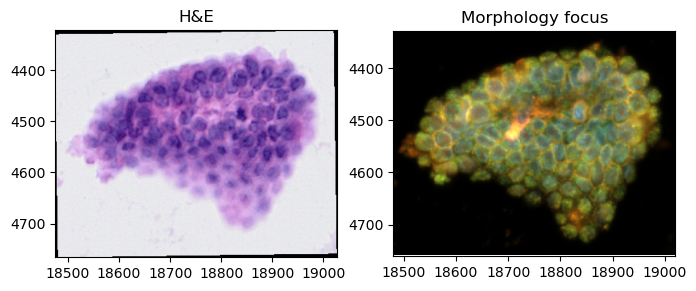

In [7]:
fig, axs = plt.subplots(ncols=2, nrows=1, figsize=(8, 3))

(
    cropped
    .pl.render_images("he_image")
    .pl.show(ax=axs[0], title="H&E")
)

(
    cropped
    .pl.render_images("morphology_focus")
    .pl.show(ax=axs[1], title="Morphology focus")
)

We can confirm this with the `get_transformation` function.

In [8]:
get_transformation(sdata["he_image"], "global")

Affine (x, y -> x, y)
    [-1.72213367e-02  1.28987110e+00 -3.65155386e+03]
    [-1.28987110e+00 -1.72213367e-02  5.16637333e+04]
    [0. 0. 1.]

To make downstream processing easier, we now bake this transformation into the image
to make downstream processing easier.

In [9]:
# get reference size to rasterize the H&E into
morph = cropped.images["morphology_focus"]
morph_extent = get_extent(morph, coordinate_system="global")
xmin, xmax = morph_extent["x"]
ymin, ymax = morph_extent["y"]

# morphology pitch = pixels per µm along each axis
# 1.0 here, but compute it to stay safe
morph_top = morph["scale0"].image if hasattr(morph, "__getitem__") else morph
ny, nx = morph_top.sizes["y"], morph_top.sizes["x"]
px_per_um_x = nx / (xmax - xmin)
px_per_um_y = ny / (ymax - ymin)
assert abs(px_per_um_x - px_per_um_y) < 1e-6, "morphology is not isotropic in global"

he_aligned = rasterize(
    cropped.images["he_image"],
    axes=("x", "y"),
    min_coordinate=[xmin, ymin],
    max_coordinate=[xmax, ymax],
    target_coordinate_system="global",
    target_unit_to_pixels=px_per_um_x,
)

cropped.images["he_aligned"] = Image2DModel.parse(
    he_aligned,
    chunks=(1, 256, 256),
    scale_factors=[2],
)


Overlaying the `he_aligned` on top of the original `he_image` shows us which parts of
the image were lost in that process - nothing important in this case.

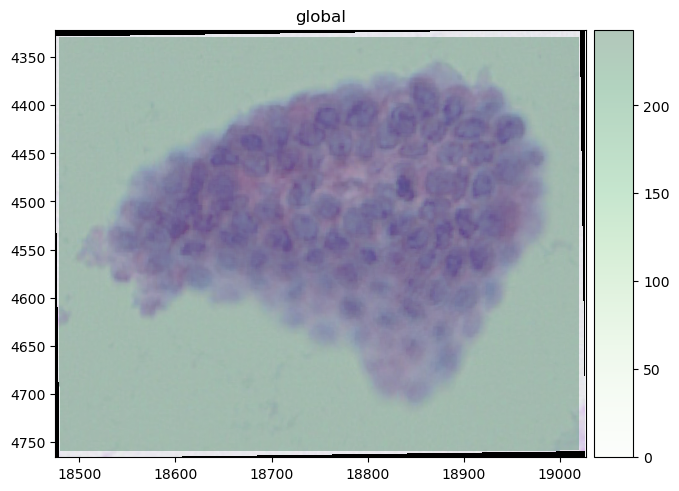

In [10]:
(
    cropped
    .pl.render_images("he_image")
    .pl.render_images("he_aligned", alpha=0.3, channel=0, cmap="Greens")
    .pl.show()
)

Inspecting the images directly also confirms that the new `he_aligned` now has the exact
same pixel dimensions as the morphology focus image.

In [11]:
cropped

SpatialData object, with associated Zarr store: /ictstr01/groups/ml01/workspace/ttreis/projects/spatialdata-notebooks/notebooks/examples/cells_dataset.zarr
├── Images
│     ├── 'he_aligned': DataTree[cyx] (3, 430, 540), (3, 215, 270)
│     ├── 'he_image': DataTree[cyx] (3, 423, 339), (3, 211, 169)
│     └── 'morphology_focus': DataTree[cyx] (4, 430, 540), (4, 215, 270)
├── Labels
│     ├── 'cell_labels': DataTree[yx] (430, 540), (215, 270)
│     └── 'nucleus_labels': DataTree[yx] (430, 540), (215, 270)
├── Points
│     └── 'transcripts': DataFrame with shape: (<Delayed>, 13) (3D points)
├── Shapes
│     ├── 'cell_boundaries': GeoDataFrame shape: (94, 1) (2D shapes)
│     └── 'nucleus_boundaries': GeoDataFrame shape: (94, 2) (2D shapes)
└── Tables
      └── 'table': AnnData (94, 5101)
with coordinate systems:
    ▸ 'global', with elements:
        he_aligned (Images), he_image (Images), morphology_focus (Images), cell_labels (Labels), nucleus_labels (Labels), transcripts (Points), cell_

The cell and nucleus segmentation masks look mostly correct - they're slightly shifted
because the H&E image in a Xenium experiment is acquired after the actual Xenium process.

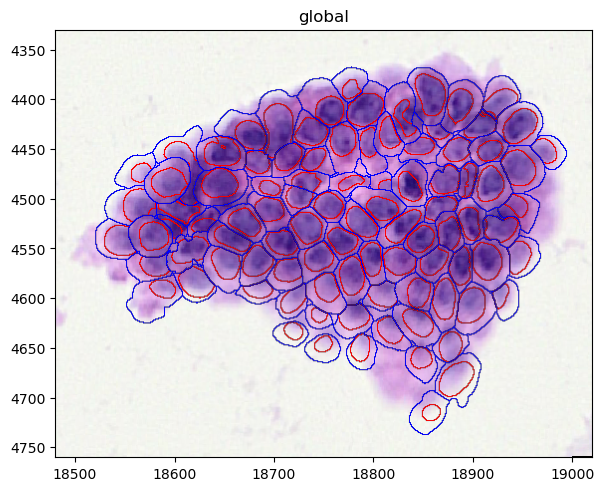

In [12]:
(
    cropped
    .pl.render_images("he_aligned")
    .pl.render_labels("nucleus_labels", color="red", outline_alpha=1, fill_alpha=0)
    .pl.render_labels("cell_labels", color="blue", outline_alpha=1, fill_alpha=0)
    .pl.show()
)

The `morphology_focus` image allows us to inspect this more cleanly.

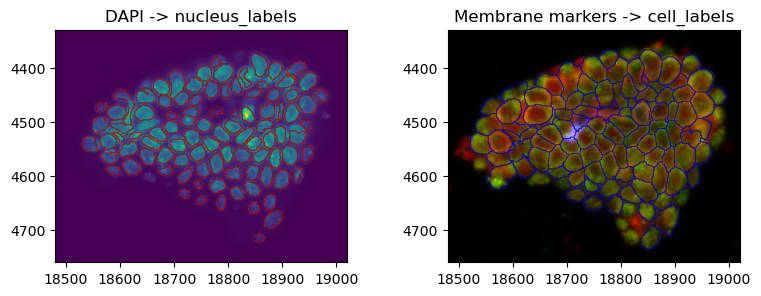

In [13]:
fig, axs = plt.subplots(ncols=2, nrows=1, figsize=(8, 3))

(
    cropped
    .pl.render_images("morphology_focus", channel="DAPI", colorbar=False)
    .pl.render_labels("nucleus_labels", color="red", outline_alpha=1, fill_alpha=0)
    # .pl.render_labels("cell_labels", color="blue", outline_alpha=1, fill_alpha=0)
    .pl.show(ax=axs[0], title="DAPI -> nucleus_labels")
)

(
    cropped
    .pl.render_images("morphology_focus", channel=["ATP1A1/CD45/E-Cadherin", "18S", "AlphaSMA/Vimentin"])
    # .pl.render_labels("nucleus_labels", color="red", outline_alpha=1, fill_alpha=0)
    .pl.render_labels("cell_labels", color="blue", outline_alpha=1, fill_alpha=0)
    .pl.show(ax=axs[1], title="Membrane markers -> cell_labels")
)

plt.tight_layout()

Let's verify that the data contains transcripts.

In [14]:
# Let's first identify a gene for which we expect a lot of transcripts.
cropped["table"].to_df().var(axis=0).sort_values()

ZNF829      0.000000
ZNF8        0.000000
ZNF346      0.000000
ZNF408      0.000000
ZNF410      0.000000
             ...    
SLC40A1     3.128346
EEF1G       3.622970
CXCL2       4.773393
THSD4       6.505262
MUC5B      11.771334
Length: 5101, dtype: float32

/ictstr01/groups/ml01/workspace/ttreis/projects/spatialdata-notebooks/notebooks/examples/.pixi/envs/default/lib/python3.14/functools.py:982: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
/ictstr01/groups/ml01/workspace/ttreis/projects/spatialdata-notebooks/notebooks/examples/.pixi/envs/default/lib/python3.14/site-packages/spatialdata_plot/pl/render.py:1017: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  cax = ax.scatter(


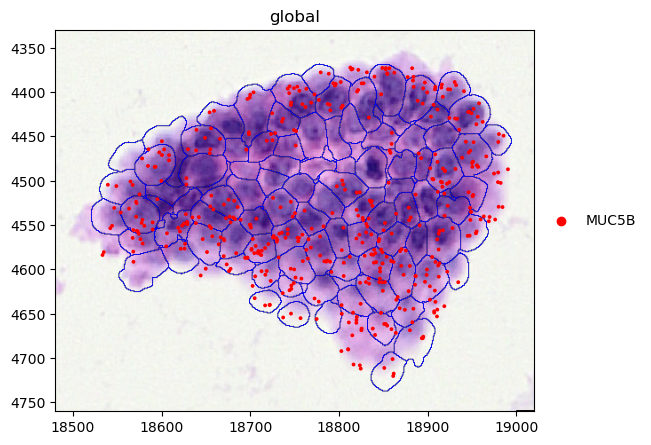

In [15]:
(
    cropped
    .pl.render_images("he_aligned")
    .pl.render_labels("cell_labels", color="blue", outline_alpha=1, fill_alpha=0)
    .pl.render_points(groups=["MUC5B"], color="feature_name", palette="red", size=3)
    .pl.show()
)

Let's also use the `detect_tissue` method in `Squidpy` to generate a border around the 
tissue element which we can use in downstream tasks. We'll use the `morphology_focus` 
image here because it provides a cleaner signal.

In [34]:
sq.experimental.im.detect_tissue(
    cropped,
    "morphology_focus",
    method="otsu",
)

INFO     Detecting tissue with method: DetectTissueMethod.OTSU                                                     
INFO     Finished segmentation.                                                                                    
INFO     Upscaling mask back to original size.                                                                     
INFO     Saved tissue mask to `sdata.labels['morphology_focus_tissue']`.                                           


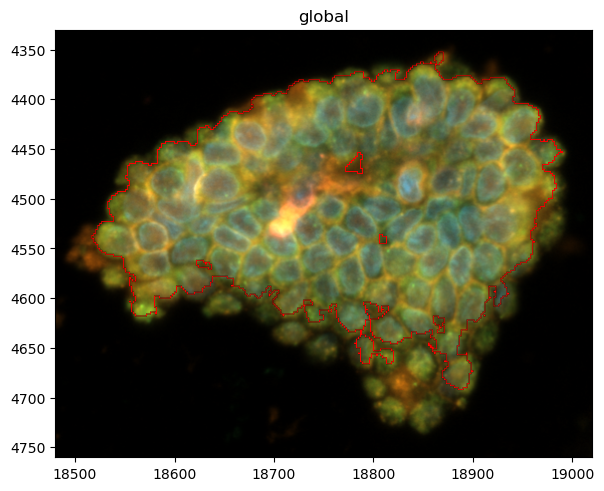

In [35]:
(
    cropped
    .pl.render_images("morphology_focus")
    .pl.render_labels(
        "morphology_focus_tissue",
        fill_alpha=0,
        outline_alpha=1,
        color="red"
    )
    .pl.show()
)

In [19]:
cropped.write("cells_dataset_final.zarr", overwrite=True)
cropped = sd.read_zarr("cells_dataset_final.zarr")

/ictstr01/groups/ml01/workspace/ttreis/projects/spatialdata-notebooks/notebooks/examples/.pixi/envs/default/lib/python3.14/contextlib.py:141: UserWarning: zarr v3 autosharding will be the default in the next minor release.
  return next(self.gen)
/ictstr01/groups/ml01/workspace/ttreis/projects/spatialdata-notebooks/notebooks/examples/.pixi/envs/default/lib/python3.14/contextlib.py:141: UserWarning: zarr v3 autosharding will be the default in the next minor release.
  return next(self.gen)
/ictstr01/groups/ml01/workspace/ttreis/projects/spatialdata-notebooks/notebooks/examples/.pixi/envs/default/lib/python3.14/contextlib.py:141: UserWarning: zarr v3 autosharding will be the default in the next minor release.
  return next(self.gen)
/ictstr01/groups/ml01/workspace/ttreis/projects/spatialdata-notebooks/notebooks/examples/.pixi/envs/default/lib/python3.14/contextlib.py:141: UserWarning: zarr v3 autosharding will be the default in the next minor release.
  return next(self.gen)
/ictstr01/gr

In [ ]:
%load_ext watermark
%watermark -v -m -p spatialdata,spatialdata_io,spatialdata_plot,squidpy,scanpy,anndata,zarr,matplotlib,pandas,numpy

Python implementation: CPython
Python version       : 3.14.4
IPython version      : 9.13.0

spatialdata     : 0.7.3
spatialdata_io  : 0.7.0
spatialdata_plot: 0.3.4
squidpy         : 1.8.1
scanpy          : 1.12.1
anndata         : 0.12.14
zarr            : 3.2.1
matplotlib      : 3.10.9
pandas          : 2.3.3
numpy           : 2.4.5

Compiler    : GCC 14.3.0
OS          : Linux
Release     : 5.14.0-570.25.1.el9_6.x86_64
Machine     : x86_64
Processor   : x86_64
CPU cores   : 96
Architecture: 64bit

